<a href="https://colab.research.google.com/github/sanjushajii/Assignments/blob/main/CVAI_Practical_Skills.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Dataset Preparation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/rice_leaf_diseases"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

class_names = list(train_data.class_indices.keys())
print("Classes:", class_names)

Found 96 images belonging to 3 classes.
Found 24 images belonging to 3 classes.
Classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


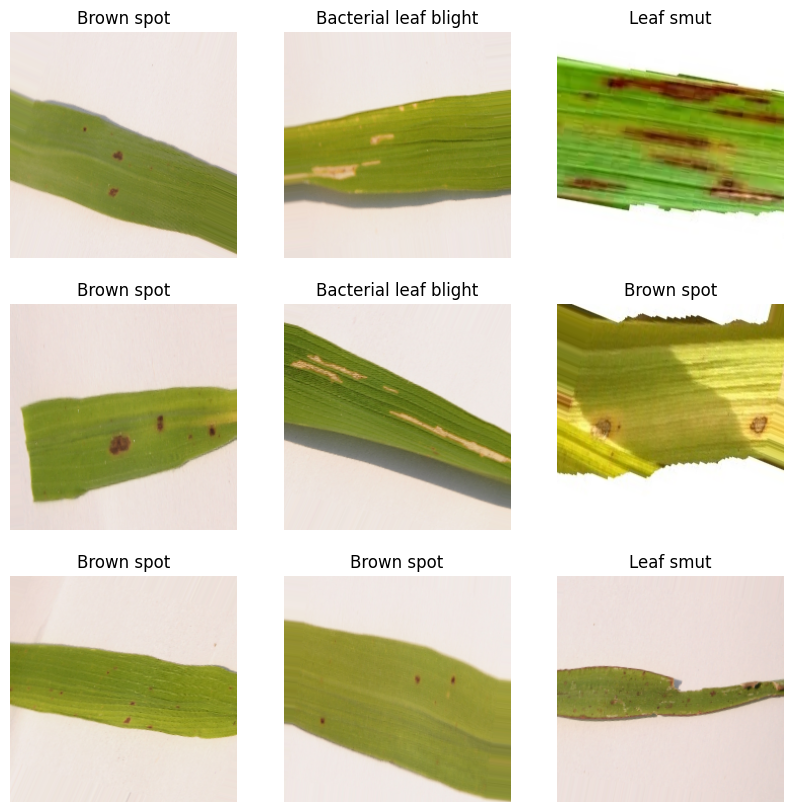

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(train_data)

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.show()

In [ ]:
#Model Architecture

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

# IMPORTANT: 3 output classes
model.add(layers.Dense(3, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Implementation

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 7s/step - accuracy: 0.5625 - loss: 1.0965 - val_accuracy: 0.7917 - val_loss: 0.6904
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.5208 - loss: 0.9920 - val_accuracy: 0.7083 - val_loss: 0.6735
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.5729 - loss: 0.8849 - val_accuracy: 0.5833 - val_loss: 0.8208
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.5938 - loss: 0.8901 - val_accuracy: 0.5000 - val_loss: 0.8949
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.5938 - loss: 0.7974 - val_accuracy: 0.5833 - val_loss: 0.8071
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.6875 - loss: 0.7080 - val_accuracy: 0.5833 - val_loss: 0.8874
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.6771 - loss: 0.6465 - val_accuracy: 0.6667 - val_loss: 0.8435
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.8125 - loss: 0.5634 - val_accuracy: 0.6667 - val_loss: 1.1269
Epoch 9/

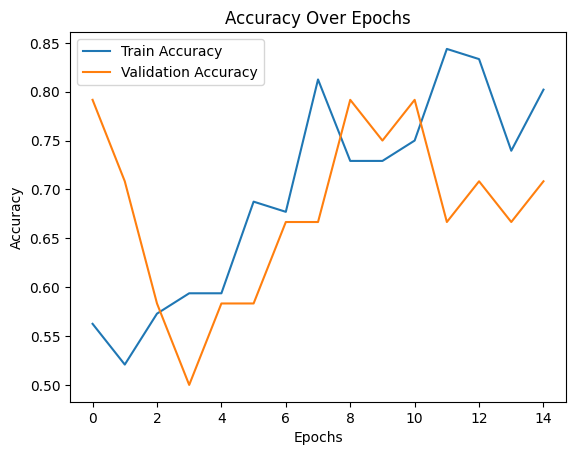

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

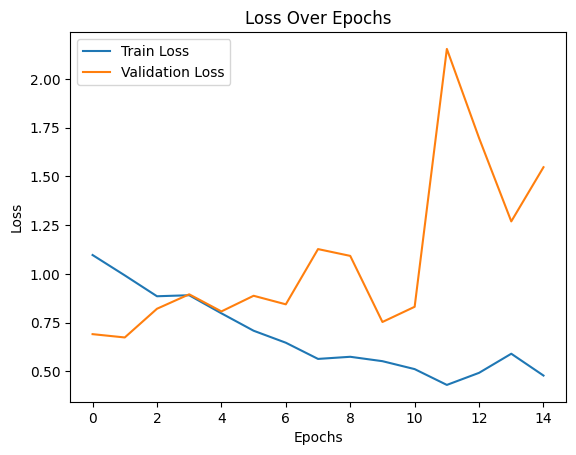

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
#Model Evaluation

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
                       precision    recall  f1-score   support

Bacterial leaf blight       0.18      0.25      0.21         8
           Brown spot       0.00      0.00      0.00         8
            Leaf smut       0.45      0.62      0.53         8

             accuracy                           0.29        24
            macro avg       0.21      0.29      0.25        24
         weighted avg       0.21      0.29      0.25        24



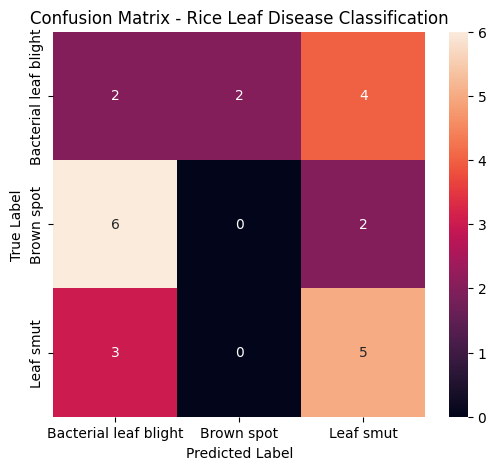

In [ ]:
val_data.reset()
predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)
y_true = val_data.classes

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix - Rice Leaf Disease Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()